In [1]:
!pip install transformers accelerate


In [2]:
!pip install transformers accelerate sentencepiece datasets tqdm pillow scikit-learn


In [3]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import json
import time
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


/home/ding-zhang/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ============================================
# CONFIGURATION - Update paths for your system
# ============================================
# Project root directory (image paths in CSV are relative to this)
# Image paths in CSV are like "dataset/lolita/image.jpg", so this should be the project root
DATA_ROOT = PROJECT_ROOT  # Used for joining with image_path from CSV

# Path to full dataset CSV
DATASET_CSV = os.path.join(PROJECT_ROOT, "data", "processed", "caption_dataset_final_full.csv")

# Results directory (will be created if doesn't exist)
EXPERIMENT_ROOT = os.path.join(PROJECT_ROOT, "experiments", "caption_eval_robustness")
METRICS_DIR = os.path.join(EXPERIMENT_ROOT, "metrics")
ARTIFACTS_DIR = os.path.join(EXPERIMENT_ROOT, "artifacts")

# ============================================
# ROBUSTNESS EVALUATION CONFIGURATION
# ============================================
NUM_SEEDS = 5  # Reduced from 10 for faster evaluation
SEED_RANGE_START = 1
SEED_RANGE_END = 500
SEED_GENERATOR_SEED = 42

# Generate 5 seeds
random.seed(SEED_GENERATOR_SEED)
SEEDS = sorted(random.sample(range(SEED_RANGE_START, SEED_RANGE_END + 1), NUM_SEEDS))

print(f"✅ Robustness Evaluation Configuration:")
print(f"   Number of seeds: {NUM_SEEDS}")
print(f"   Seeds: {SEEDS}")
print(f"   Metrics: CLIP Similarity, CLIP-IQA, BLIP Score, Diversity")
print(f"   Data root: {DATA_ROOT}")
print(f"   Experiment: {EXPERIMENT_ROOT}")

# Create results directory
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(os.path.join(METRICS_DIR, "experiments"), exist_ok=True)

# Save seeds list
with open(os.path.join(METRICS_DIR, "seeds_list.txt"), 'w') as f:
    f.write(f"Robustness Evaluation Seeds\n")
    f.write(f"{'='*50}\n")
    f.write(f"Total seeds: {NUM_SEEDS}\n")
    f.write(f"Range: {SEED_RANGE_START}-{SEED_RANGE_END}\n")
    f.write(f"Generator seed: {SEED_GENERATOR_SEED}\n")
    f.write(f"{'='*50}\n\n")
    for i, seed in enumerate(SEEDS, 1):
        f.write(f"{i:2d}. Seed {seed}\n")
print(f"✅ Seeds list saved to: {os.path.join(METRICS_DIR, 'seeds_list.txt')}")


✅ Robustness Evaluation Configuration:
   Number of seeds: 5
   Seeds: [13, 58, 141, 328, 380]
   Metrics: CLIP Similarity, CLIP-IQA, BLIP Score, Diversity
   Data root: /home/ding-zhang/Dongmei/DATA255/Project
   Results dir: /home/ding-zhang/Dongmei/DATA255/Project/caption_evaluation_robustness_results
✅ Seeds list saved to: /home/ding-zhang/Dongmei/DATA255/Project/caption_evaluation_robustness_results/seeds_list.txt


In [5]:
# Load full dataset
full_df = pd.read_csv(DATASET_CSV)
print(f"✅ Loaded full dataset: {len(full_df)} samples")
print(f"   Columns: {list(full_df.columns)}")
full_df.head()



✅ Loaded full dataset: 13230 samples
   Columns: ['image_path', 'style', 'caption', 'status']


,image_path,style,caption,status
0,dataset/conservative/o0300040012191914250.jpg,conservative,The image depicts a woman dressed in a stylish...,success
1,dataset/conservative/coord_04.jpg,conservative,"In the image, a woman wearing a coat and holdi...",success
2,dataset/conservative/20161027122232_2048995902...,conservative,"The image features a woman, likely of Asian de...",success
3,dataset/conservative/1874.jpg,conservative,"In the image, two women are walking down a sid...",success
4,dataset/conservative/main20160421171142.jpg,conservative,The image features a woman wearing a white jac...,success


In [6]:
from transformers import CLIPProcessor, CLIPModel

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


2025-12-04 14:05:05.516643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-04 14:05:05.542962: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-04 14:05:06.162076: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ding-zhang/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/huggingface_hub/file_do

In [7]:
from transformers import CLIPTokenizer

clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

def truncate_caption_for_clip(caption, max_len=77):
    tokens = clip_tokenizer(
        caption,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return clip_tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)


In [8]:
def compute_clip_similarity(image_path, caption):
    """Compute CLIP similarity with robust error handling for missing files"""
    from urllib.parse import unquote
    
    # Handle URL-encoded paths and construct full path
    if '%' in image_path:
        path_parts = image_path.split('/')
        decoded_parts = [unquote(part) if '%' in part else part for part in path_parts]
        image_path = '/'.join(decoded_parts)
    
    # Construct full path (image_path from CSV is relative to PROJECT_ROOT)
    if not os.path.isabs(image_path):
        full_path = os.path.join(DATA_ROOT, image_path)
    else:
        full_path = image_path
    
    # Check if file exists, return None if not
    if not os.path.exists(full_path):
        return None
    
    try:
        image = Image.open(full_path).convert("RGB")
        caption_short = truncate_caption_for_clip(caption)
        
        inputs = clip_processor(
            text=[caption_short],
            images=image,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)
        
        with torch.no_grad():
            logits = clip_model(**inputs).logits_per_image
        
        return logits.item()
    except Exception as e:
        # Return None for any error (missing file, corrupted image, etc.)
        return None


In [9]:
def add_clip_similarity(df):
    """Add CLIP similarity scores to dataframe, handling missing files gracefully"""
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Pass raw image_path from CSV - compute_clip_similarity will handle path construction
        score = compute_clip_similarity(row["image_path"], row["caption"])
        scores.append(score)
    df["clip_similarity"] = scores
    return df


In [10]:
def compute_clip_iqa(df, n_negatives=10):
    """Compute CLIP-IQA scores with robust error handling
    Reduced n_negatives from 20 to 10 for faster computation (~50% speedup)"""
    scores = []
    all_caps = list(df["caption"])

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        # Pass raw image_path from CSV - compute_clip_similarity will handle path construction
        pos = compute_clip_similarity(row["image_path"], row["caption"])
        if pos is None:
            scores.append(0.0)
            continue
        
        neg_samples = random.sample(all_caps, min(n_negatives, len(all_caps)))
        neg_scores = [compute_clip_similarity(row["image_path"], c) for c in neg_samples]
        neg_scores = [s for s in neg_scores if s is not None]
        
        if len(neg_scores) == 0:
            scores.append(0.0)
            continue
            
        neg_mean = np.mean(neg_scores)
        scores.append(float(pos - neg_mean))

    df["clip_iqa"] = scores
    return df


In [11]:
from transformers import BlipProcessor, BlipForImageTextRetrieval

blip_model = BlipForImageTextRetrieval.from_pretrained(
    "Salesforce/blip-itm-base-coco"
).to(device)

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-itm-base-coco")


In [12]:
def compute_blip_score(image_path, caption):
    """Compute BLIP score with robust error handling for missing files"""
    from urllib.parse import unquote
    
    # Handle URL-encoded paths and construct full path
    if '%' in image_path:
        path_parts = image_path.split('/')
        decoded_parts = [unquote(part) if '%' in part else part for part in path_parts]
        image_path = '/'.join(decoded_parts)
    
    # Construct full path (image_path from CSV is relative to PROJECT_ROOT)
    if not os.path.isabs(image_path):
        full_path = os.path.join(DATA_ROOT, image_path)
    else:
        full_path = image_path
    
    # Check if file exists, return None if not
    if not os.path.exists(full_path):
        return None
    
    try:
        image = Image.open(full_path).convert("RGB")
        
        inputs = blip_processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)
        
        with torch.no_grad():
            outputs = blip_model(**inputs)
            score = outputs.itm_score.mean().item()
        
        return score
    except Exception as e:
        # Return None for any error (missing file, corrupted image, etc.)
        return None



In [13]:
def add_blip_scores(df):
    """Add BLIP scores to dataframe, handling missing files gracefully"""
    scores = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        # Pass raw image_path from CSV - compute_blip_score will handle path construction
        score = compute_blip_score(row["image_path"], row["caption"])
        scores.append(score)
    df["blip_score"] = scores
    return df


In [14]:
# Add label column for stratified splitting
styles = [
    "conservative", "dressy", "ethnic", "fairy", "feminine",
    "gal", "girlish", "kireime-casual", "lolita", "mode",
    "natural", "retro", "rock", "street"
]
style2id = {s:i for i,s in enumerate(styles)}
full_df["label"] = full_df["style"].map(style2id)
print(f"✅ Style mapping created: {len(styles)} styles")


✅ Style mapping created: 14 styles


In [15]:
# CaptionDataset and DataLoader are not needed anymore
# (removed with classifier code - we only compute caption quality metrics now)


In [16]:
# Load BERT model for diversity computation
fb_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
fb_model = AutoModel.from_pretrained("bert-base-uncased").to(device)
print("✅ BERT model loaded for diversity computation")


/home/ding-zhang/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✅ BERT model loaded for diversity computation


In [17]:
def train_one_epoch():
    model.train()
    total, correct, loss_sum = 0, 0, 0
    for batch in tqdm(train_loader):
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += len(labels)

    return loss_sum/len(train_loader), correct/total


def eval_model(loader):
    model.eval()
    total, correct = 0, 0
    preds_all = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, mask)
            preds = logits.argmax(1)
            preds_all.extend(preds.cpu().tolist())

            correct += (preds == labels).sum().item()
            total += len(labels)

    return correct/total, preds_all


In [18]:
# Diversity computation function
def embed_caption(caption):
    tokens = fb_tokenizer(
        caption,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        output = fb_model(**tokens)
        cls_emb = output.last_hidden_state[:,0,:].squeeze(0)
    return cls_emb.cpu().numpy()

def compute_diversity(df, sample_size=500):
    """Compute diversity metric with reduced sample size for faster computation"""
    sample = df.sample(min(len(df), sample_size), random_state=42)
    embeddings = np.stack([embed_caption(c) for c in sample["caption"]])
    sim_matrix = cosine_similarity(embeddings)
    sims = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
    return float(1 - sims.mean())


## Robustness Evaluation: Run Experiments Across 10 Seeds


In [ ]:
# Store all results
all_results = []

print("="*80)
print("STARTING ROBUSTNESS EVALUATION")
print("="*80)
print(f"Total experiments: {NUM_SEEDS}")
print(f"Seeds: {SEEDS}\n")

for seed_idx, seed_value in enumerate(SEEDS, 1):
    print(f"\n{'='*80}")
    print(f"EXPERIMENT {seed_idx}/{NUM_SEEDS} - Seed: {seed_value}")
    print(f"{'='*80}")
    
    start_time = time.time()
    
    # Set seed for data splitting
    np.random.seed(seed_value)
    random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    
    # Split data with this seed
    train_df, temp_df = train_test_split(
        full_df, 
        test_size=0.3, 
        random_state=seed_value, 
        stratify=full_df["label"]
    )
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=0.5, 
        random_state=seed_value, 
        stratify=temp_df["label"]
    )
    
    print(f"  Data split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
    
    # Compute CLIP similarity, CLIP-IQA, and BLIP scores
    print("  Computing CLIP similarity...")
    train_df = add_clip_similarity(train_df.copy())
    val_df = add_clip_similarity(val_df.copy())
    test_df = add_clip_similarity(test_df.copy())
    
    print("  Computing CLIP-IQA...")
    train_df = compute_clip_iqa(train_df.copy(), n_negatives=10)
    val_df = compute_clip_iqa(val_df.copy(), n_negatives=10)
    test_df = compute_clip_iqa(test_df.copy(), n_negatives=10)
    
    print("  Computing BLIP scores...")
    train_df = add_blip_scores(train_df.copy())
    val_df = add_blip_scores(val_df.copy())
    test_df = add_blip_scores(test_df.copy())
    
    # Compute diversity
    print("  Computing diversity...")
    div_train = compute_diversity(train_df)
    div_val = compute_diversity(val_df)
    div_test = compute_diversity(test_df)
    
    # Store results
    result = {
        "seed_value": seed_value,
        "seed_idx": seed_idx,
        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
        "diversity": {
            "train": div_train,
            "val": div_val,
            "test": div_test
        },
        "clip_metrics": {
            "train_mean_similarity": train_df["clip_similarity"].mean(),
            "val_mean_similarity": val_df["clip_similarity"].mean(),
            "test_mean_similarity": test_df["clip_similarity"].mean(),
            "train_mean_iqa": train_df["clip_iqa"].mean(),
            "val_mean_iqa": val_df["clip_iqa"].mean(),
            "test_mean_iqa": test_df["clip_iqa"].mean(),
        },
        "blip_metrics": {
            "train_mean": train_df["blip_score"].mean(),
            "val_mean": val_df["blip_score"].mean(),
            "test_mean": test_df["blip_score"].mean(),
        },
        "time_minutes": (time.time() - start_time) / 60.0
    }
    
    all_results.append(result)
    
    # Save individual result
    result_file = os.path.join(RESULTS_DIR, "experiments", f"seed_{seed_value}_results.json")
    with open(result_file, 'w') as f:
        json.dump(result, f, indent=2)
    
    print(f"  ✅ Experiment {seed_idx} completed in {result['time_minutes']:.2f} minutes")
    print(f"     Test CLIP Similarity: {result['clip_metrics']['test_mean_similarity']:.4f}")
    print(f"     Test CLIP-IQA: {result['clip_metrics']['test_mean_iqa']:.4f}")
    print(f"     Test BLIP Score: {result['blip_metrics']['test_mean']:.4f}")

print(f"\n{'='*80}")
print("ALL EXPERIMENTS COMPLETED")
print(f"{'='*80}")
print(f"Total experiments: {len(all_results)}")


STARTING ROBUSTNESS EVALUATION
Total experiments: 5
Seeds: [13, 58, 141, 328, 380]


EXPERIMENT 1/5 - Seed: 13
  Data split: Train=9261, Val=1984, Test=1985
  Computing CLIP similarity...


100%|██████████| 1985/1985 [00:20<00:00, 94.72it/s] 


  Computing CLIP-IQA...


100%|██████████| 1985/1985 [03:06<00:00, 10.66it/s]


  Computing BLIP scores...


...

  Computing CLIP-IQA...


100%|██████████| 1985/1985 [03:05<00:00, 10.69it/s]


  Computing BLIP scores...


100%|██████████| 1985/1985 [00:28<00:00, 69.11it/s]


  Computing diversity...
  ✅ Experiment 5 completed in 26.00 minutes
     Test CLIP Similarity: 29.9688
     Test CLIP-IQA: 9.3071
     Test BLIP Score: -0.0025

ALL EXPERIMENTS COMPLETED
Total experiments: 5


## Post-Processing: Add Per-Class and Overall Metrics to Existing Results

**Run this cell if you already completed experiments and want to add per-class/overall metrics to existing results.**

This will:
- Load existing result JSON files
- For each seed, recreate the data split and recompute metrics (needed for per-class analysis)
- Compute per-class metrics for each split
- Compute overall metrics (across all splits combined)
- Update the JSON files with new metrics


In [ ]:
# ============================================
# POST-PROCESSING: Add Per-Class and Overall Metrics
# ============================================
# This cell processes existing results and adds per-class/overall metrics
# without affecting the main robustness evaluation loop

print("="*80)
print("POST-PROCESSING: Adding Per-Class and Overall Metrics")
print("="*80)

# Load existing results from JSON files
existing_results = []
results_dir = os.path.join(RESULTS_DIR, "experiments")

for seed_value in SEEDS:
    result_file = os.path.join(results_dir, f"seed_{seed_value}_results.json")
    if os.path.exists(result_file):
        with open(result_file, 'r') as f:
            existing_results.append(json.load(f))
        print(f"  ✅ Loaded: seed_{seed_value}_results.json")
    else:
        print(f"  ⚠️  Missing: seed_{seed_value}_results.json")

print(f"\nLoaded {len(existing_results)} existing results")

if len(existing_results) == 0:
    print("⚠️  No existing results found! Please run experiments first.")
else:
    # Process each existing result
    updated_results = []
    
    for result in existing_results:
        seed_value = result["seed_value"]
        print(f"\n{'='*80}")
        print(f"Processing Seed {seed_value}...")
        print(f"{'='*80}")
        
        # Check if already has per-class metrics
        if "per_class_metrics" in result and "overall_metrics" in result:
            print(f"  ⏭️  Seed {seed_value} already has per-class/overall metrics, skipping...")
            updated_results.append(result)
            continue
        
        start_time = time.time()
        
        # Recreate the same data split using the same seed
        np.random.seed(seed_value)
        random.seed(seed_value)
        torch.manual_seed(seed_value)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed_value)
        
        # Split data with this seed (same as original)
        train_df, temp_df = train_test_split(
            full_df, 
            test_size=0.3, 
            random_state=seed_value, 
            stratify=full_df["label"]
        )
        val_df, test_df = train_test_split(
            temp_df, 
            test_size=0.5, 
            random_state=seed_value, 
            stratify=temp_df["label"]
        )
        
        print(f"  Data split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
        
        # Check if saved dataframes with per-image scores exist
        dataframes_dir = os.path.join(RESULTS_DIR, "dataframes")
        os.makedirs(dataframes_dir, exist_ok=True)
        
        train_df_file = os.path.join(dataframes_dir, f"seed_{seed_value}_train.csv")
        val_df_file = os.path.join(dataframes_dir, f"seed_{seed_value}_val.csv")
        test_df_file = os.path.join(dataframes_dir, f"seed_{seed_value}_test.csv")
        
        if (os.path.exists(train_df_file) and os.path.exists(val_df_file) and os.path.exists(test_df_file)):
            print("  ✅ Found saved dataframes with per-image scores, loading...")
            train_df = pd.read_csv(train_df_file)
            val_df = pd.read_csv(val_df_file)
            test_df = pd.read_csv(test_df_file)
            print("  ✅ Loaded saved dataframes (no recomputation needed!)")
        else:
            print("  ⚠️  No saved dataframes found, computing metrics (this will take time)...")
            print("  Computing CLIP similarity...")
            train_df = add_clip_similarity(train_df.copy())
            val_df = add_clip_similarity(val_df.copy())
            test_df = add_clip_similarity(test_df.copy())
            
            print("  Computing CLIP-IQA...")
            train_df = compute_clip_iqa(train_df.copy(), n_negatives=10)
            val_df = compute_clip_iqa(val_df.copy(), n_negatives=10)
            test_df = compute_clip_iqa(test_df.copy(), n_negatives=10)
            
            print("  Computing BLIP scores...")
            train_df = add_blip_scores(train_df.copy())
            val_df = add_blip_scores(val_df.copy())
            test_df = add_blip_scores(test_df.copy())
            
            # Save dataframes for future use
            print("  💾 Saving dataframes for future use...")
            train_df.to_csv(train_df_file, index=False)
            val_df.to_csv(val_df_file, index=False)
            test_df.to_csv(test_df_file, index=False)
            print("  ✅ Dataframes saved!")
        
        # Compute per-class metrics
        print("  Computing per-class metrics...")
        per_class_train = compute_per_class_metrics(train_df, "train")
        per_class_val = compute_per_class_metrics(val_df, "val")
        per_class_test = compute_per_class_metrics(test_df, "test")
        
        # Compute overall metrics
        print("  Computing overall metrics...")
        overall_metrics = compute_overall_metrics(train_df, val_df, test_df)
        
        # Update result with new metrics
        result["per_class_metrics"] = {
            "train": per_class_train,
            "val": per_class_val,
            "test": per_class_test
        }
        result["overall_metrics"] = overall_metrics
        
        # Save updated result
        result_file = os.path.join(results_dir, f"seed_{seed_value}_results.json")
        with open(result_file, 'w') as f:
            json.dump(result, f, indent=2)
        
        processing_time = (time.time() - start_time) / 60.0
        print(f"  ✅ Seed {seed_value} updated in {processing_time:.2f} minutes")
        
        updated_results.append(result)
    
    # Update all_results for statistical analysis
    all_results = updated_results
    
    print(f"\n{'='*80}")
    print(f"POST-PROCESSING COMPLETED")
    print(f"{'='*80}")
    print(f"Updated {len(updated_results)} result files")
    print(f"All results now include per-class and overall metrics!")
    print(f"\n✅ You can now run the Statistical Analysis cell to see per-class statistics.")


POST-PROCESSING: Adding Per-Class and Overall Metrics
  ✅ Loaded: seed_13_results.json
  ✅ Loaded: seed_58_results.json
  ✅ Loaded: seed_141_results.json
  ✅ Loaded: seed_328_results.json
  ✅ Loaded: seed_380_results.json

Loaded 5 existing results

Processing Seed 13...
  Data split: Train=9261, Val=1984, Test=1985
  Computing CLIP similarity...


 90%|████████▉ | 8311/9261 [01:21<00:09, 101.37it/s]


KeyboardInterrupt: 

## Statistical Analysis: Robustness Metrics


In [ ]:
def calculate_stats(values, name):
    """Calculate comprehensive statistics for a metric"""
    mean_val = np.mean(values)
    std_val = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    median_val = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    cv = (std_val / mean_val * 100) if mean_val != 0 else 0  # Coefficient of Variation
    
    # 95% Confidence Interval
    if len(values) > 1:
        ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))
        ci_lower, ci_upper = ci
    else:
        ci_lower, ci_upper = mean_val, mean_val
    
    return {
        "metric": name,
        "mean": float(mean_val),
        "std": float(std_val),
        "min": float(min_val),
        "max": float(max_val),
        "median": float(median_val),
        "q25": float(q25),
        "q75": float(q75),
        "cv_percent": float(cv),
        "ci_95_lower": float(ci_lower),
        "ci_95_upper": float(ci_upper),
        "n": len(values)
    }

if len(all_results) > 0:
    # Extract metrics
    div_tests = [r['diversity']['test'] for r in all_results]
    clip_test_sims = [r['clip_metrics']['test_mean_similarity'] for r in all_results]
    clip_test_iqa = [r['clip_metrics']['test_mean_iqa'] for r in all_results]
    blip_test = [r['blip_metrics']['test_mean'] for r in all_results]
    times = [r['time_minutes'] for r in all_results]
    
    # Create statistics table
    stats_data = [
        calculate_stats(clip_test_sims, "Test CLIP Similarity"),
        calculate_stats(clip_test_iqa, "Test CLIP-IQA"),
        calculate_stats(blip_test, "Test BLIP Score"),
        calculate_stats(div_tests, "Test Diversity"),
        calculate_stats(times, "Time (min)")
    ]
    
    df_stats = pd.DataFrame(stats_data)
    
    print("\n" + "="*80)
    print("STATISTICAL SUMMARY - Robustness Experiments")
    print("="*80)
    print(df_stats.to_string(index=False))
    
    # Save statistics
    stats_path = os.path.join(RESULTS_DIR, "statistical_analysis.json")
    with open(stats_path, 'w') as f:
        json.dump({
            "summary": stats_data,
            "individual_results": all_results,
            "seeds_used": SEEDS,
            "num_experiments": len(all_results)
        }, f, indent=2)
    
    # Save CSV
    df_stats.to_csv(os.path.join(RESULTS_DIR, "statistical_summary.csv"), index=False)
    
    print(f"\n✅ Statistics saved to:")
    print(f"   - {stats_path}")
    print(f"   - {os.path.join(RESULTS_DIR, 'statistical_summary.csv')}")
else:
    print("⚠️  No results found! Please run experiments first.")



STATISTICAL SUMMARY - Robustness Experiments
              metric      mean      std       min       max    median       q25       q75  cv_percent  ci_95_lower  ci_95_upper  n
Test CLIP Similarity 29.964185 0.041857 29.902811 30.033946 29.960911 29.954455 29.968800    0.139690    29.906078    30.022291  5
       Test CLIP-IQA  9.333630 0.030622  9.303244  9.376968  9.317027  9.307131  9.363781    0.328078     9.291121     9.376140  5
     Test BLIP Score -0.002480 0.000026 -0.002522 -0.002445 -0.002486 -0.002486 -0.002463   -1.040374    -0.002516    -0.002444  5
      Test Diversity  0.122773 0.000820  0.121766  0.123696  0.123145  0.121818  0.123439    0.667799     0.121635     0.123911  5
          Time (min) 26.310368 0.627173 25.962932 27.563825 26.001660 25.987555 26.035866    2.383747    25.439713    27.181023  5

✅ Statistics saved to:
   - /home/ding-zhang/Dongmei/DATA255/Project/caption_evaluation_robustness_results/statistical_analysis.json
   - /home/ding-zhang/Dongmei/DATA

## Visualization: Robustness Results


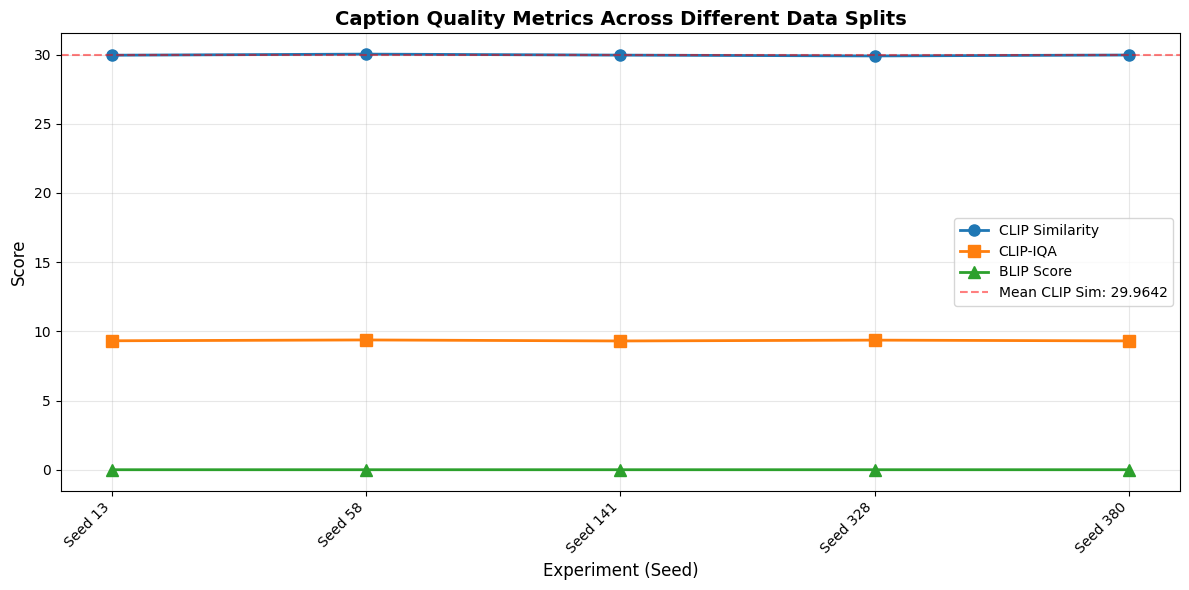

/tmp/ipykernel_18489/3442890961.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([div_trains, div_vals, div_tests], labels=['Train', 'Val', 'Test'])
/tmp/ipykernel_18489/3442890961.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([clip_train_sims, clip_test_sims], labels=['Train', 'Test'])
/tmp/ipykernel_18489/3442890961.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([clip_train_iqa, clip_test_iqa], labels=['Train', 'Test'])


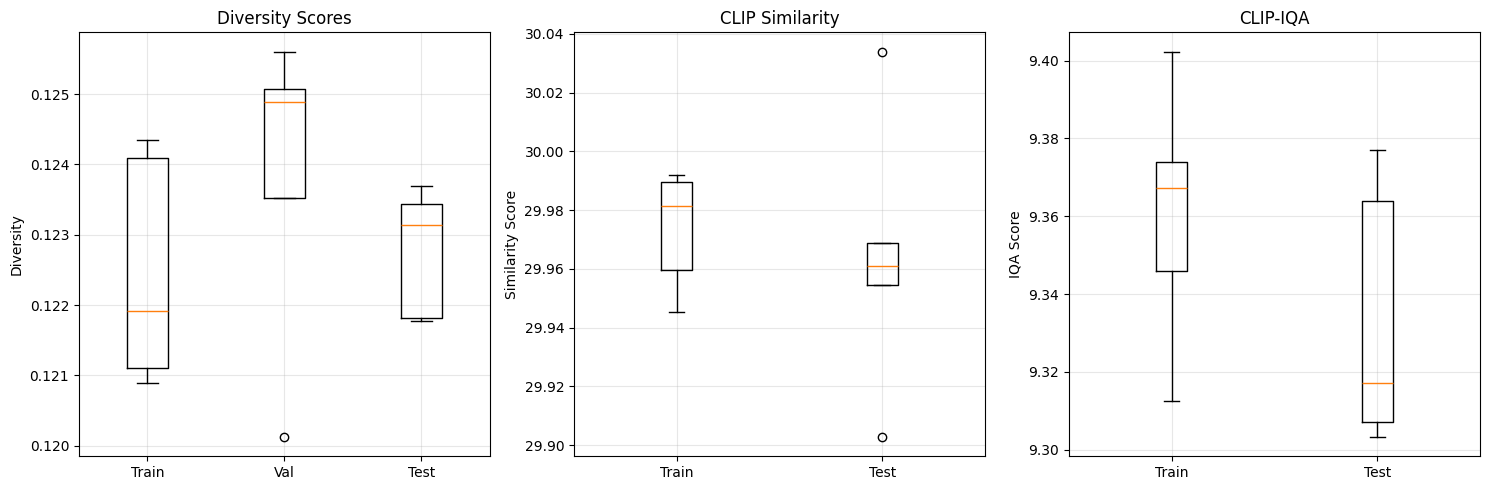

✅ Visualizations saved to: /home/ding-zhang/Dongmei/DATA255/Project/caption_evaluation_robustness_results


In [21]:
if len(all_results) > 0:
    # Extract metrics for visualization
    div_trains = [r['diversity']['train'] for r in all_results]
    div_vals = [r['diversity']['val'] for r in all_results]
    div_tests = [r['diversity']['test'] for r in all_results]
    clip_train_sims = [r['clip_metrics']['train_mean_similarity'] for r in all_results]
    clip_test_sims = [r['clip_metrics']['test_mean_similarity'] for r in all_results]
    clip_train_iqa = [r['clip_metrics']['train_mean_iqa'] for r in all_results]
    clip_test_iqa = [r['clip_metrics']['test_mean_iqa'] for r in all_results]
    blip_test = [r['blip_metrics']['test_mean'] for r in all_results]
    
    # Plot 1: Metrics across seeds
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(1, len(all_results) + 1)
    ax.plot(x, clip_test_sims, 'o-', label='CLIP Similarity', linewidth=2, markersize=8)
    ax.plot(x, clip_test_iqa, 's-', label='CLIP-IQA', linewidth=2, markersize=8)
    ax.plot(x, blip_test, '^-', label='BLIP Score', linewidth=2, markersize=8)
    ax.axhline(y=np.mean(clip_test_sims), color='r', linestyle='--', alpha=0.5, label=f'Mean CLIP Sim: {np.mean(clip_test_sims):.4f}')
    ax.set_xlabel('Experiment (Seed)', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Caption Quality Metrics Across Different Data Splits', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Seed {r['seed_value']}" for r in all_results], rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "caption_quality_across_seeds.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Plot 2: Box plots for diversity and CLIP metrics
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].boxplot([div_trains, div_vals, div_tests], labels=['Train', 'Val', 'Test'])
    axes[0].set_title('Diversity Scores')
    axes[0].set_ylabel('Diversity')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].boxplot([clip_train_sims, clip_test_sims], labels=['Train', 'Test'])
    axes[1].set_title('CLIP Similarity')
    axes[1].set_ylabel('Similarity Score')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].boxplot([clip_train_iqa, clip_test_iqa], labels=['Train', 'Test'])
    axes[2].set_title('CLIP-IQA')
    axes[2].set_ylabel('IQA Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "diversity_clip_metrics.png"), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Visualizations saved to: {RESULTS_DIR}")
else:
    print("⚠️  No results found! Please run experiments first.")


In [ ]:
def build_per_class_eval(df):
    stats = []
    for style in styles:
        sub = df[df["style"] == style]
        stats.append({
            "style": style,
            "count": len(sub),
            "mean_clip_similarity": sub["clip_similarity"].mean(),
            "mean_clip_iqa": sub["clip_iqa"].mean(),
            "mean_blip_score": sub["blip_score"].mean(),
            "classifier_accuracy": sub["classifier_correct"].mean(),
        })
    return pd.DataFrame(stats)

per_class_train = build_per_class_eval(train_df)
per_class_val   = build_per_class_eval(val_df)
per_class_test  = build_per_class_eval(test_df)

per_class_train.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_class_train.csv", index=False)
per_class_val.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_class_val.csv", index=False)
per_class_test.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_class_test.csv", index=False)


In [ ]:
def embed_caption(caption):
    tokens = fb_tokenizer(
        caption,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = fb_model(**tokens)
        cls_emb = output.last_hidden_state[:,0,:].squeeze(0)
    return cls_emb.cpu().numpy()

def compute_diversity(df, sample_size=500):
    """Compute diversity metric with reduced sample size for faster computation"""
    sample = df.sample(min(len(df), sample_size), random_state=42)
    embeddings = np.stack([embed_caption(c) for c in sample["caption"]])
    sim_matrix = cosine_similarity(embeddings)
    sims = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
    return float(1 - sims.mean())

div_train = compute_diversity(train_df)
div_val   = compute_diversity(val_df)
div_test  = compute_diversity(test_df)

print("Diversity scores:")
print("Train =", div_train)
print("Val   =", div_val)
print("Test  =", div_test)

# save to txt
with open("/content/drive/MyDrive/data255/captionEvaluation/diversity_scores.txt", "w") as f:
    f.write(f"train={div_train}\nval={div_val}\ntest={div_test}\n")


Diversity scores:
Train = 0.8715630769729614
Val   = 0.8728731870651245
Test  = 0.877049446105957


In [ ]:
model_path = "/content/drive/MyDrive/data255/fashionbert_style_classifier.pt"
torch.save(model.state_dict(), model_path)
print("Model saved to:", model_path)


Model saved to: /content/drive/MyDrive/data255/fashionbert_style_classifier.pt


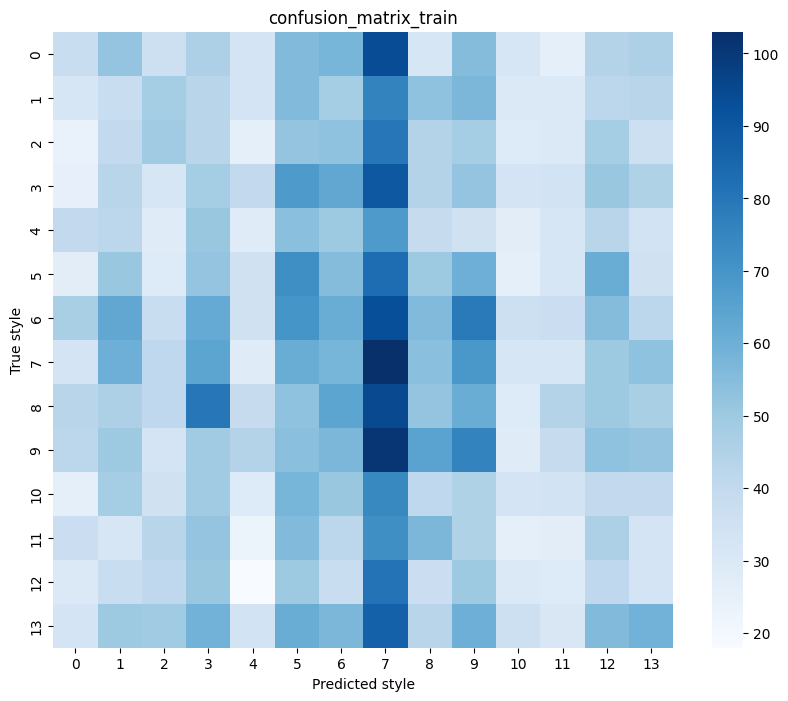

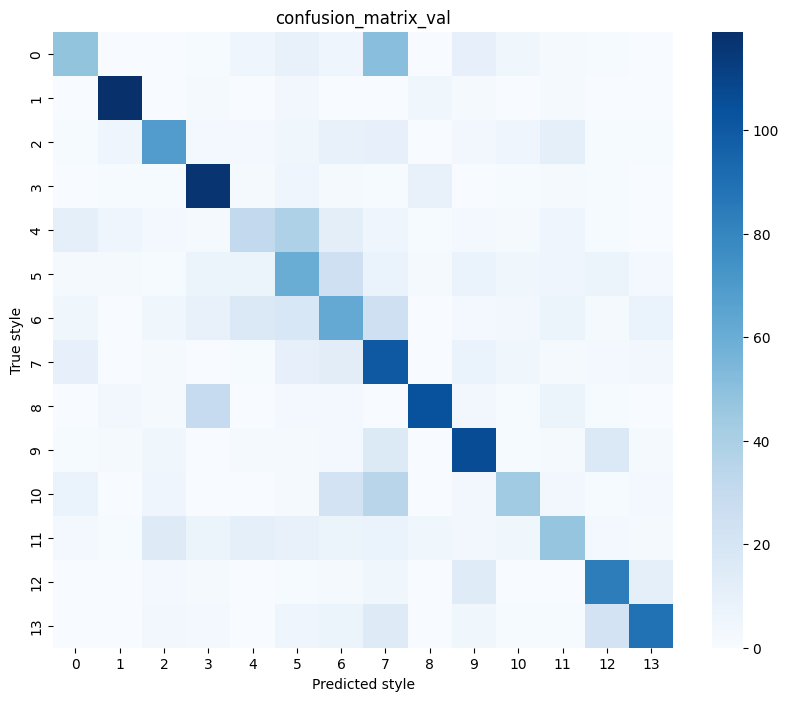

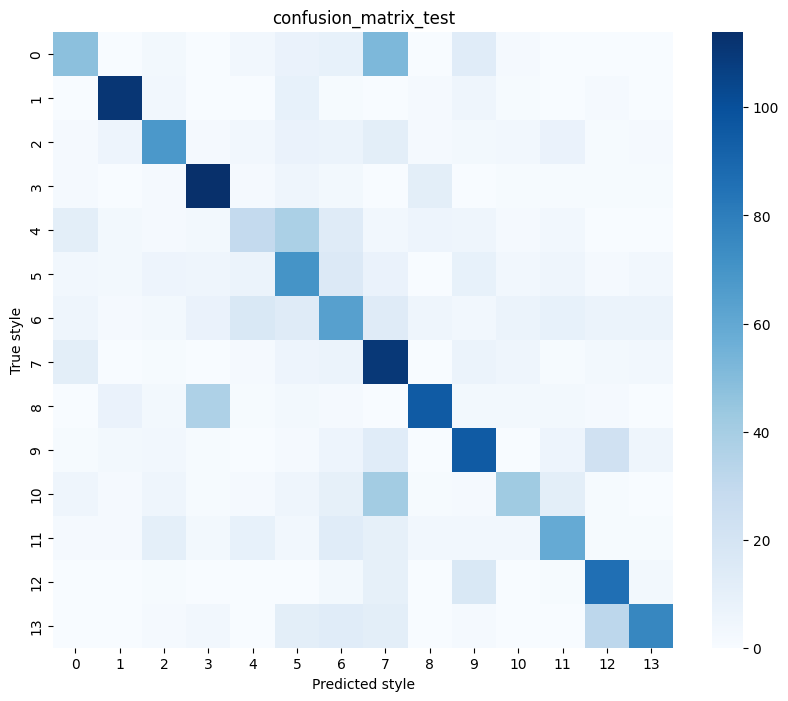

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def compute_cm(df, filename):
    cm = confusion_matrix(df["label"], df["predicted_style"])
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(filename)
    plt.ylabel("True style")
    plt.xlabel("Predicted style")
    plt.savefig(f"/content/drive/MyDrive/{filename}.png", dpi=300)
    plt.show()
    return cm

cm_train = compute_cm(train_df, "confusion_matrix_train")
cm_val   = compute_cm(val_df, "confusion_matrix_val")
cm_test  = compute_cm(test_df, "confusion_matrix_test")


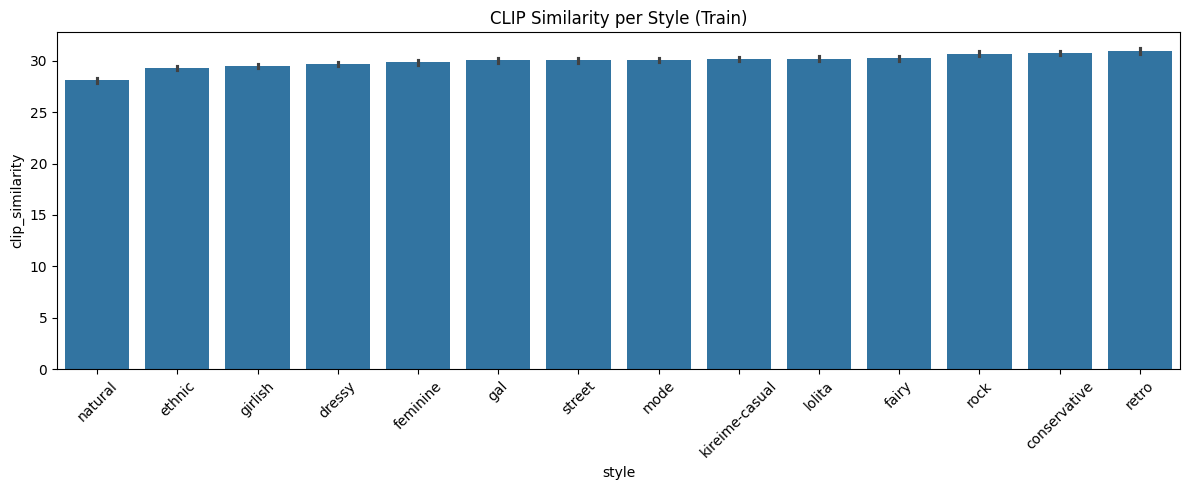

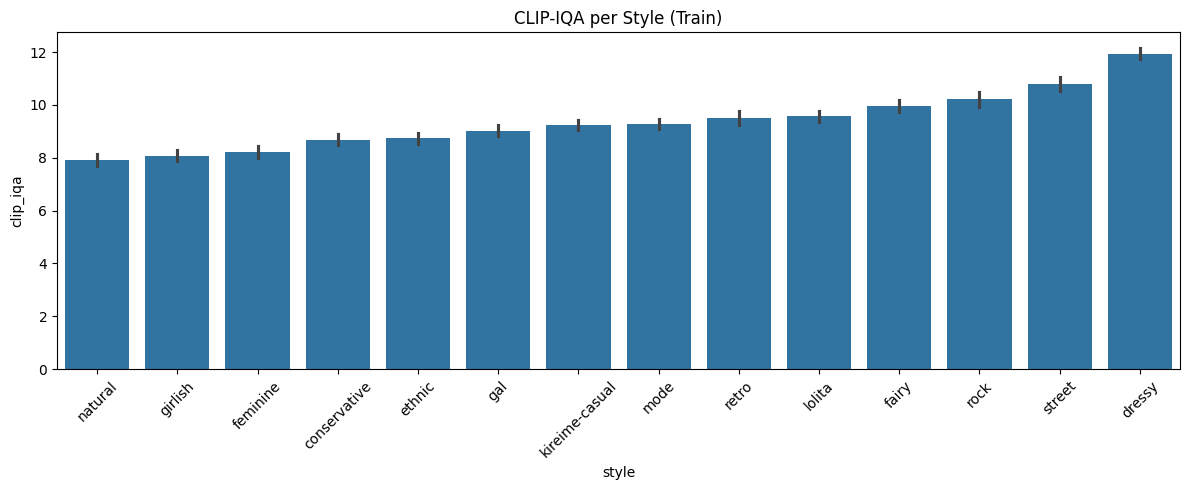

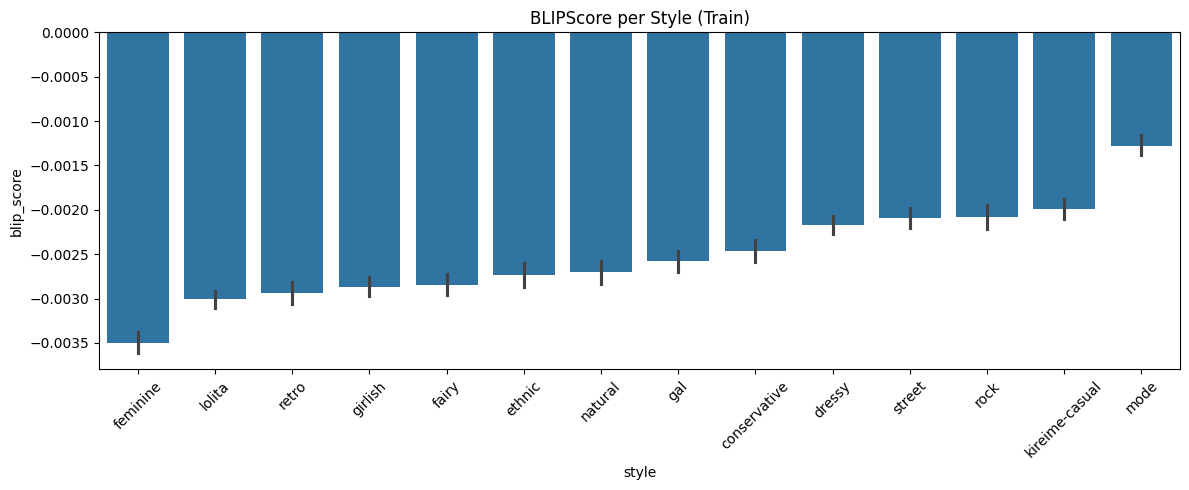

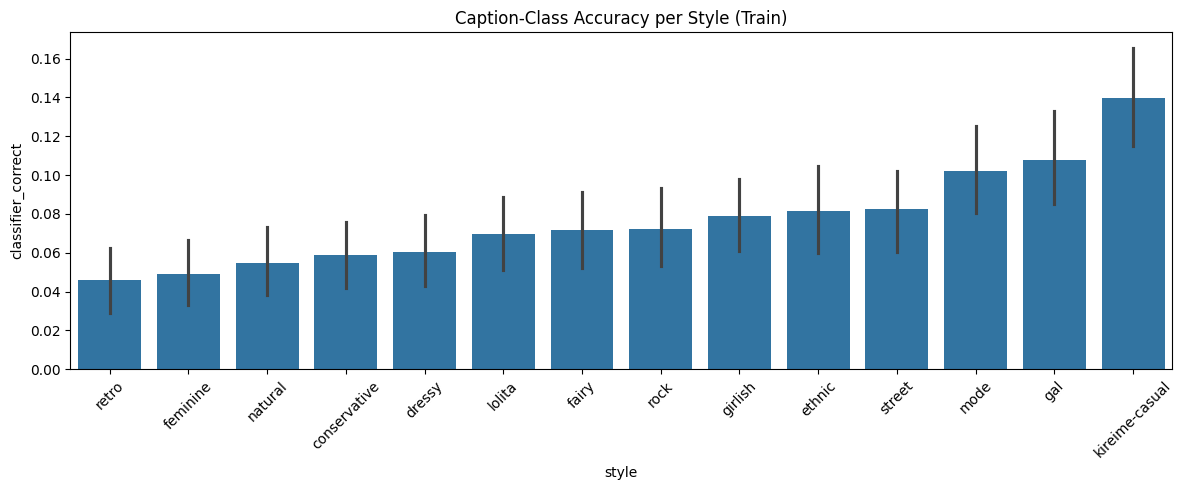

In [ ]:
def plot_metric(df, metric, title):
    plt.figure(figsize=(12,5))
    order = df.groupby("style")[metric].mean().sort_values().index
    sns.barplot(data=df, x="style", y=metric, order=order)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/{metric}_per_style.png", dpi=300)
    plt.show()

plot_metric(train_df, "clip_similarity", "CLIP Similarity per Style (Train)")
plot_metric(train_df, "clip_iqa", "CLIP-IQA per Style (Train)")
plot_metric(train_df, "blip_score", "BLIPScore per Style (Train)")
plot_metric(train_df, "classifier_correct", "Caption-Class Accuracy per Style (Train)")


In [ ]:
import json

summary = {
    "diversity": {
        "train": div_train,
        "val": div_val,
        "test": div_test
    },
    "per_class_train": per_class_train.to_dict(orient="records"),
    "per_class_val": per_class_val.to_dict(orient="records"),
    "per_class_test": per_class_test.to_dict(orient="records"),
    "notes": "Generated by multimodal-caption-evaluation pipeline."
}

with open("/content/drive/MyDrive/data255/captionEvaluation/evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("JSON summary saved!")


JSON summary saved!


In [ ]:
train_df.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_image_train_progress.csv", index=False)
val_df.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_image_val_progress.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/data255/captionEvaluation/per_image_test_progress.csv", index=False)
